# TP53 - qualitative analysis

In [96]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [54]:
# loading mmrf df
mmrf_tp53_df = pd.read_csv("mmrf_tp53_filtered(2).tsv", sep="\t", index_col=0)
mmrf_tp53_df

,ENST00000269305,ENST00000420246,ENST00000455263,ENST00000504937,ENST00000510385
PUBLIC_ID,,,,,
MMRF_1021,596,398,0,0,0
MMRF_1024,2349,109,0,0,0
MMRF_1029,2003,517,0,16,0
MMRF_1030,1245,195,0,15,0
MMRF_1031,2330,200,0,11,0
...,...,...,...,...,...
MMRF_2843,147,730,0,254,0
MMRF_2847,512,391,0,45,0
MMRF_2848,0,250,0,0,0


In [3]:
# loading tp53 df
tp53_df = pd.read_csv("tp53_isoforms.tsv", sep="\t", index_col=0)
tp53_df

,isoform,ensembl_ID,class,long_short,TA
0,p53alpha,ENST00000269305,alpha,long,1
1,p53beta,ENST00000420246,beta,long,1
2,p53gamma,ENST00000455263,gamma,long,1
3,delta40p53alpha,ENST00000619485,alpha,long,1
4,delta40p53beta,ENST00000622645,beta,long,1
5,delta133p53alpha,ENST00000504937,alpha,short,0
6,delta160p53alpha,ENST00000619186,alpha,short,0
7,delta133p53beta,ENST00000510385,beta,short,0


**NB:** Isoforms $\small\Delta40p53\alpha$, $\small\Delta40p53\beta$, and $\small\Delta160p53\alpha$ are not present in CoMMpass data.
Missing isoforms will be defined as `NA`; `expressing!=0`; `non_expressing==0`.

In [10]:
#filtering tp53 df - removing missing isoforms
tp53_df = tp53_df[tp53_df.ensembl_ID.isin(mmrf_tp53_df.columns)]
tp53_df

,isoform,ensembl_ID,class,long_short,TA
0,p53alpha,ENST00000269305,alpha,long,1
1,p53beta,ENST00000420246,beta,long,1
2,p53gamma,ENST00000455263,gamma,long,1
5,delta133p53alpha,ENST00000504937,alpha,short,0
7,delta133p53beta,ENST00000510385,beta,short,0


In [178]:
#creating arrays that classifies isoforms based on categories as above

##totp53/alpha
tot_0_1=[1 if i!=0 else 0 for i in mmrf_tp53_df.iloc[:, 0]]

##class beta
beta_0_1=[1 if i!=0 else 0 for i in mmrf_tp53_df.iloc[:, 1]]

##class gamma
gamma_0_1=[1 if i!=0 else 0 for i in mmrf_tp53_df.iloc[:, 2]]

##long

##short

##TA

In [161]:
group = np.array(["expressing", "non_expressing"]*2)
values = [np.unique(tot_0_1, return_counts=True)[1][1], np.unique(tot_0_1, return_counts=True)[1][0], #totp53
         np.unique(gamma_0_1, return_counts=True)[1][1], np.unique(gamma_0_1, return_counts=True)[1][0]] #gamma
cat = np.concatenate(np.array([2*["total_p53"], 2*["gamma"]]))
df = pd.DataFrame({'variable': cat,'group': group, 'value': values})
df

,variable,group,value
0,total_p53,expressing,697
1,total_p53,non_expressing,36
2,gamma,expressing,214
3,gamma,non_expressing,519


<AxesSubplot: xlabel='value', ylabel='variable'>

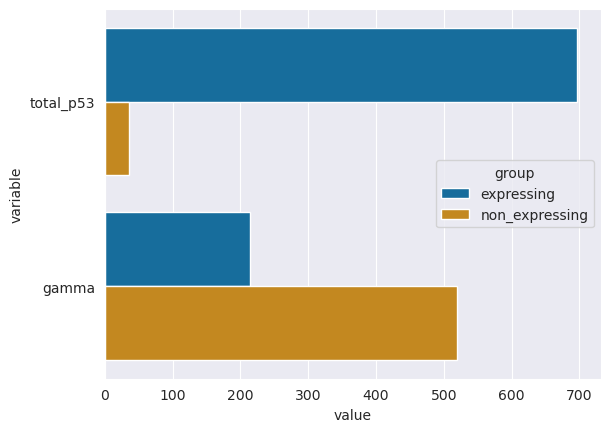

In [167]:
sns.barplot(data=df, x="value", y="variable", hue="group", estimator=sum, palette="colorblind", legend=True)

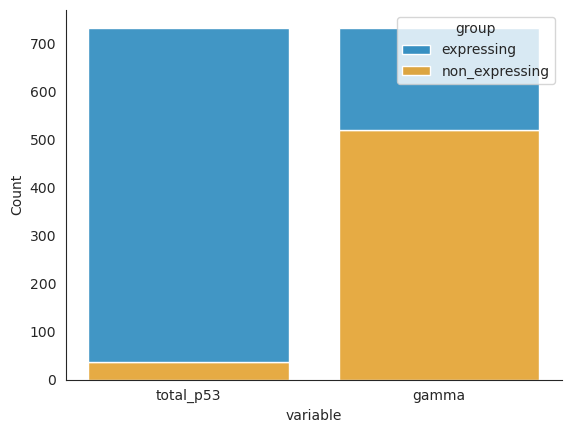

In [177]:
sns.set_style("white")
sns.histplot(df, x='variable', hue='group', weights='value', multiple='stack', palette='colorblind', shrink=0.8)
sns.despine()